In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_evergreen_conifer = pd.read_csv(r"D:\wenqu\chapter1_2\chapter2\pft_spectra\pft_spectra\evergreen_conifer.csv")
df_evergreen_conifer

,site_quadrant,PFT,cover,b1_mean,b2_mean,b3_mean,b4_mean,b5_mean,b6_mean,b7_mean,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S1B_01,evergreen_conifer,0.003175,0.008066,0.005356,0.005069,0.003740,0.003234,0.004096,0.003448,...,0.041609,0.043572,0.038524,0.041291,0.040247,0.039954,0.036505,0.034067,0.037205,0.042243
1,S1B_14,evergreen_conifer,0.008584,0.013563,0.009756,0.007837,0.006729,0.006789,0.006688,0.005570,...,0.082741,0.080296,0.077248,0.074408,0.085448,0.073635,0.073669,0.075640,0.080911,0.088266
2,S2A_11,evergreen_conifer,0.002212,0.037116,0.028136,0.027556,0.022787,0.022009,0.021122,0.018811,...,0.147961,0.148489,0.137109,0.141940,0.147016,0.137352,0.143938,0.143416,0.132508,0.157942
3,S2A_13,evergreen_conifer,0.005423,0.013592,0.017636,0.015679,0.011988,0.009930,0.009121,0.008895,...,0.048441,0.044967,0.039642,0.039218,0.035964,0.038140,0.039319,0.033442,0.040686,0.052364
4,S2A_20,evergreen_conifer,0.001029,0.039751,0.031147,0.029295,0.017796,0.016078,0.016646,0.016124,...,0.076808,0.071154,0.064541,0.076027,0.072932,0.065979,0.076477,0.066554,0.071955,0.085123
5,S2A_22,evergreen_conifer,0.010152,0.009314,0.027679,0.022682,0.019915,0.017593,0.018475,0.017304,...,0.062603,0.057242,0.053887,0.053506,0.057938,0.053175,0.050132,0.048109,0.054293,0.057513


In [3]:
df_licen_spectra = pd.read_csv(r"D:\wenqu\chapter1_2\chapter2\pft_spectra\pft_spectra\lichen_spectra.csv")
df_graminoid_spectra = pd.read_csv("D:/wenqu/chapter1_2/chapter2/pft_spectra/pft_spectra/graminoid_spectra.csv", skip_blank_lines=True)
df_non_veg_spectra = pd.read_csv(r"D:\wenqu\chapter1_2\chapter2\pft_spectra\pft_spectra\non_veg_spectra.csv") 
df_forb_spectra = pd.read_csv(r"D:\wenqu\chapter1_2\chapter2\pft_spectra\pft_spectra\forb_spectra.csv") 
df_evergreen_shrub_spectra = pd.read_csv(r"D:\wenqu\chapter1_2\chapter2\pft_spectra\pft_spectra\evergreen_shrub_spectra.csv") 
df_deciduous_shrub_spectra = pd.read_csv(r"D:\wenqu\chapter1_2\chapter2\pft_spectra\pft_spectra\deciduous_shrub_spectra.csv") 
df_standing_dead = pd.read_csv(r"D:\wenqu\chapter1_2\chapter2\pft_spectra\pft_spectra\standing_dead_spectra.csv") 
df_deciduous_shrub_spectra

,site_quadrant,pft,cover,b1_mean,b2_mean,b3_mean,b4_mean,b5_mean,b6_mean,b7_mean,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S1B_01,Deciduous_shrub,0.155556,0.008066,0.005356,0.005069,0.003740,0.003234,0.004096,0.003448,...,0.041609,0.043572,0.038524,0.041291,0.040247,0.039954,0.036505,0.034067,0.037205,0.042243
1,S1B_02,Deciduous_shrub,0.278689,0.007073,0.005461,0.006265,0.004865,0.004999,0.004671,0.004856,...,0.072257,0.075493,0.069805,0.067690,0.075395,0.067074,0.066255,0.067615,0.064345,0.071650
2,S1B_03,Deciduous_shrub,0.258621,0.007469,0.007563,0.005852,0.008872,0.007166,0.008688,0.008907,...,0.073458,0.073482,0.068208,0.066982,0.075305,0.071986,0.065947,0.071657,0.076951,0.080836
3,S1B_04,Deciduous_shrub,0.245690,0.007599,0.007815,0.005624,0.005231,0.005647,0.006165,0.005041,...,0.105415,0.108488,0.112840,0.104882,0.108871,0.105052,0.105640,0.101807,0.108830,0.106154
4,S1B_05,Deciduous_shrub,0.790323,0.012442,0.004747,0.003768,0.004511,0.003534,0.003922,0.003383,...,0.118789,0.107213,0.116077,0.109012,0.116640,0.108828,0.115047,0.114928,0.112759,0.109147
5,S1B_06,Deciduous_shrub,0.270042,0.013019,0.009587,0.010217,0.009804,0.008983,0.009972,0.010341,...,0.071753,0.071114,0.070022,0.066585,0.067130,0.063679,0.068098,0.068896,0.075916,0.079351
6,S1B_08,Deciduous_shrub,0.410959,0.009560,0.005217,0.004406,0.004180,0.004491,0.004933,0.004617,...,0.092260,0.086733,0.084757,0.079991,0.087949,0.082367,0.085009,0.083780,0.092286,0.090650
7,S1B_09,Deciduous_shrub,0.293333,0.015077,0.008629,0.008274,0.008792,0.008029,0.008785,0.007826,...,0.082134,0.074957,0.071745,0.074409,0.077037,0.071356,0.072356,0.070620,0.083389,0.084606
8,S1B_10,Deciduous_shrub,0.331839,0.009731,0.006944,0.006660,0.004985,0.005775,0.005698,0.006839,...,0.083011,0.078096,0.082652,0.070200,0.079887,0.074142,0.078799,0.080803,0.084301,0.079994
9,S1B_12,Deciduous_shrub,0.409091,0.015963,0.009181,0.009470,0.006101,0.006833,0.007718,0.005744,...,0.138250,0.147516,0.145039,0.133949,0.140592,0.138326,0.134143,0.137214,0.149233,0.140250


In [4]:
b_name_mean = []
b_name_std = []
for i in range(1, 123):
    b_mean = 'b' + str(i) + '_mean'
    b_name_mean.append(b_mean)
    b_std = 'b' + str(i) + '_std'
    b_name_std.append(b_std)
band_name = b_name_mean + b_name_std
band_name = np.array(band_name)
band_name

array(['b1_mean', 'b2_mean', 'b3_mean', 'b4_mean', 'b5_mean', 'b6_mean',
       'b7_mean', 'b8_mean', 'b9_mean', 'b10_mean', 'b11_mean',
       'b12_mean', 'b13_mean', 'b14_mean', 'b15_mean', 'b16_mean',
       'b17_mean', 'b18_mean', 'b19_mean', 'b20_mean', 'b21_mean',
       'b22_mean', 'b23_mean', 'b24_mean', 'b25_mean', 'b26_mean',
       'b27_mean', 'b28_mean', 'b29_mean', 'b30_mean', 'b31_mean',
       'b32_mean', 'b33_mean', 'b34_mean', 'b35_mean', 'b36_mean',
       'b37_mean', 'b38_mean', 'b39_mean', 'b40_mean', 'b41_mean',
       'b42_mean', 'b43_mean', 'b44_mean', 'b45_mean', 'b46_mean',
       'b47_mean', 'b48_mean', 'b49_mean', 'b50_mean', 'b51_mean',
       'b52_mean', 'b53_mean', 'b54_mean', 'b55_mean', 'b56_mean',
       'b57_mean', 'b58_mean', 'b59_mean', 'b60_mean', 'b61_mean',
       'b62_mean', 'b63_mean', 'b64_mean', 'b65_mean', 'b66_mean',
       'b67_mean', 'b68_mean', 'b69_mean', 'b70_mean', 'b71_mean',
       'b72_mean', 'b73_mean', 'b74_mean', 'b75_mean', 'b76

In [5]:
len(band_name)  

244

In [6]:
x_conifer = np.array(df_licen_spectra[band_name])

In [7]:
x_licen = np.array(df_licen_spectra[band_name])
x_graminoid = np.array(df_graminoid_spectra[band_name])
x_nonveg = np.array(df_non_veg_spectra[band_name])

x_forb = np.array(df_forb_spectra[band_name])
x_evergreen_shrub = np.array(df_evergreen_shrub_spectra[band_name])
x_deciduous_shrub = np.array(df_deciduous_shrub_spectra[band_name])
x_standing_dead = np.array(df_standing_dead[band_name])

In [8]:
labels_conifer = [] 
for i in range(len(df_evergreen_conifer['site_quadrant'])):    
    site_name = df_evergreen_conifer['site_quadrant'][i].split("_")[0]
    labels_conifer.append(site_name)

In [9]:
labels_forb = [] 
for i in range(len(df_forb_spectra['site_quadrant'])):    
    site_name = df_forb_spectra['site_quadrant'][i].split("_")[0]
    labels_forb.append(site_name)

In [10]:
labels_evergreen_shrub = [] 
for i in range(len(df_evergreen_shrub_spectra['site_quadrant'])):    
    site_name = df_evergreen_shrub_spectra['site_quadrant'][i].split("_")[0]
    labels_evergreen_shrub.append(site_name)

In [11]:
labels_deciduous_shrub = [] 
for i in range(len(df_deciduous_shrub_spectra['site_quadrant'])):    
    site_name = df_deciduous_shrub_spectra['site_quadrant'][i].split("_")[0]
    labels_deciduous_shrub.append(site_name)

In [12]:
labels_standing_dead = [] 
for i in range(len(df_standing_dead['site_quadrant'])):    
    site_name = df_standing_dead['site_quadrant'][i].split("_")[0]
    labels_standing_dead.append(site_name)

In [13]:
labels_nonveg = [] 
for i in range(len(df_non_veg_spectra['site_quadrant'])):    
    site_name = df_non_veg_spectra['site_quadrant'][i].split("_")[0]
    labels_nonveg.append(site_name)


labels_nonveg

['S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A']

In [14]:
labels_licen = [] 
for i in range(len(df_licen_spectra['site_quadrant'])):
    
    site_name = df_licen_spectra['site_quadrant'][i].split("_")[0]

    labels_licen.append(site_name)
labels_licen

['S1B',
 'S1B',
 'S1B',
 'S1B',
 'S1B',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S2A',
 'S6A',
 'S6A',
 'S6A']

In [15]:
labels_graminoid = []

for val in df_graminoid_spectra['site_quadrant']:
    if pd.notna(val):  # Check for non-NaN
        site_name = str(val).split("_")[0]
    else:
        site_name = 'unknown'  # or use np.nan, or skip
    labels_graminoid.append(site_name)


In [16]:
df_graminoid_spectra

,site_quadrant,pft,cover,b1_mean,b2_mean,b3_mean,b4_mean,b5_mean,b6_mean,b7_mean,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S1B_01,Graminoid,0.044444,0.008066,0.005356,0.005069,0.003740,0.003234,0.004096,0.003448,...,0.041609,0.043572,0.038524,0.041291,0.040247,0.039954,0.036505,0.034067,0.037205,0.042243
1,S1B_02,Graminoid,0.008197,0.007073,0.005461,0.006265,0.004865,0.004999,0.004671,0.004856,...,0.072257,0.075493,0.069805,0.067690,0.075395,0.067074,0.066255,0.067615,0.064345,0.071650
2,S1B_03,Graminoid,0.068966,0.007469,0.007563,0.005852,0.008872,0.007166,0.008688,0.008907,...,0.073458,0.073482,0.068208,0.066982,0.075305,0.071986,0.065947,0.071657,0.076951,0.080836
3,S1B_04,Graminoid,0.008621,0.007599,0.007815,0.005624,0.005231,0.005647,0.006165,0.005041,...,0.105415,0.108488,0.112840,0.104882,0.108871,0.105052,0.105640,0.101807,0.108830,0.106154
4,S1B_05,Graminoid,0.209677,0.012442,0.004747,0.003768,0.004511,0.003534,0.003922,0.003383,...,0.118789,0.107213,0.116077,0.109012,0.116640,0.108828,0.115047,0.114928,0.112759,0.109147
5,S1B_06,Graminoid,0.135021,0.013019,0.009587,0.010217,0.009804,0.008983,0.009972,0.010341,...,0.071753,0.071114,0.070022,0.066585,0.067130,0.063679,0.068098,0.068896,0.075916,0.079351
6,S1B_08,Graminoid,0.004566,0.009560,0.005217,0.004406,0.004180,0.004491,0.004933,0.004617,...,0.092260,0.086733,0.084757,0.079991,0.087949,0.082367,0.085009,0.083780,0.092286,0.090650
7,S1B_09,Graminoid,0.004444,0.015077,0.008629,0.008274,0.008792,0.008029,0.008785,0.007826,...,0.082134,0.074957,0.071745,0.074409,0.077037,0.071356,0.072356,0.070620,0.083389,0.084606
8,S1B_10,Graminoid,0.215247,0.009731,0.006944,0.006660,0.004985,0.005775,0.005698,0.006839,...,0.083011,0.078096,0.082652,0.070200,0.079887,0.074142,0.078799,0.080803,0.084301,0.079994
9,S1B_11,Graminoid,0.031469,0.009178,0.006943,0.004953,0.004245,0.004165,0.004981,0.004887,...,0.074817,0.073934,0.075564,0.070180,0.075976,0.070316,0.071065,0.073488,0.078000,0.081847


In [17]:
y_conifer = df_evergreen_conifer['cover'].to_numpy()
y_graminoid = df_graminoid_spectra['cover'].to_numpy()

In [18]:
df_graminoid_spectra

,site_quadrant,pft,cover,b1_mean,b2_mean,b3_mean,b4_mean,b5_mean,b6_mean,b7_mean,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S1B_01,Graminoid,0.044444,0.008066,0.005356,0.005069,0.003740,0.003234,0.004096,0.003448,...,0.041609,0.043572,0.038524,0.041291,0.040247,0.039954,0.036505,0.034067,0.037205,0.042243
1,S1B_02,Graminoid,0.008197,0.007073,0.005461,0.006265,0.004865,0.004999,0.004671,0.004856,...,0.072257,0.075493,0.069805,0.067690,0.075395,0.067074,0.066255,0.067615,0.064345,0.071650
2,S1B_03,Graminoid,0.068966,0.007469,0.007563,0.005852,0.008872,0.007166,0.008688,0.008907,...,0.073458,0.073482,0.068208,0.066982,0.075305,0.071986,0.065947,0.071657,0.076951,0.080836
3,S1B_04,Graminoid,0.008621,0.007599,0.007815,0.005624,0.005231,0.005647,0.006165,0.005041,...,0.105415,0.108488,0.112840,0.104882,0.108871,0.105052,0.105640,0.101807,0.108830,0.106154
4,S1B_05,Graminoid,0.209677,0.012442,0.004747,0.003768,0.004511,0.003534,0.003922,0.003383,...,0.118789,0.107213,0.116077,0.109012,0.116640,0.108828,0.115047,0.114928,0.112759,0.109147
5,S1B_06,Graminoid,0.135021,0.013019,0.009587,0.010217,0.009804,0.008983,0.009972,0.010341,...,0.071753,0.071114,0.070022,0.066585,0.067130,0.063679,0.068098,0.068896,0.075916,0.079351
6,S1B_08,Graminoid,0.004566,0.009560,0.005217,0.004406,0.004180,0.004491,0.004933,0.004617,...,0.092260,0.086733,0.084757,0.079991,0.087949,0.082367,0.085009,0.083780,0.092286,0.090650
7,S1B_09,Graminoid,0.004444,0.015077,0.008629,0.008274,0.008792,0.008029,0.008785,0.007826,...,0.082134,0.074957,0.071745,0.074409,0.077037,0.071356,0.072356,0.070620,0.083389,0.084606
8,S1B_10,Graminoid,0.215247,0.009731,0.006944,0.006660,0.004985,0.005775,0.005698,0.006839,...,0.083011,0.078096,0.082652,0.070200,0.079887,0.074142,0.078799,0.080803,0.084301,0.079994
9,S1B_11,Graminoid,0.031469,0.009178,0.006943,0.004953,0.004245,0.004165,0.004981,0.004887,...,0.074817,0.073934,0.075564,0.070180,0.075976,0.070316,0.071065,0.073488,0.078000,0.081847


In [19]:
y_licen = df_licen_spectra['cover'].to_numpy()
y_nonveg = df_non_veg_spectra['cover'].to_numpy()

In [20]:
y_forb = df_forb_spectra['cover'].to_numpy()
y_evergreen_shrub = df_evergreen_shrub_spectra['cover'].to_numpy()
y_deciduous_shrub = df_deciduous_shrub_spectra['cover'].to_numpy()
y_standing_dead = df_standing_dead['cover'].to_numpy()

In [21]:
y_nonveg

array([0.28571429, 0.49180328, 0.13793103, 0.24137931, 0.01687764,
       0.42666667, 0.03587444, 0.10909091, 0.16304348, 0.19685039,
       0.02666667, 0.24539877, 0.09615385, 0.04907976, 0.015625  ,
       0.06472492, 0.11173184, 0.37313433, 0.08412198, 0.04878049,
       0.14814815, 0.02561913, 0.07619048, 0.19305019, 0.24242424,
       0.05961252, 0.22123894, 0.07633588, 0.43383948, 0.0456621 ,
       0.03603604, 0.23225807, 0.02040816, 0.04115226, 0.03571429,
       0.20304569, 0.02      , 0.03571429, 0.02197802])

In [22]:
def optimise_pls_band_component(X, y, max_comp):
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    n_samples, n_features = X.shape
    results = []
    total_iters = max_comp * n_features
    iter_count = 0

    for n_comp in range(1, max_comp + 1):
        for n_discard in range(n_features - n_comp + 1):
            X_used = X[:, n_discard:]
            if X_used.shape[1] < n_comp:
                continue
            pls = PLSRegression(n_components=n_comp)
            y_cv = cross_val_predict(pls, X_used, y, cv=n_samples)
            mse = mean_squared_error(y, y_cv)
            results.append((n_comp, n_discard, mse))
            iter_count += 1
            percent = 100 * iter_count / total_iters
            stdout.write(f"\rComponent: {n_comp}, Features left for inner loop: {n_features - n_discard}, {percent:.0f}% completed")
            stdout.flush()
    stdout.write("\n")

    results_np = np.array(results)
    mse_all = results_np[:, 2]
    min_idx = np.argmin(mse_all)
    best_n_comp = int(results_np[min_idx, 0])
    best_n_discard = int(results_np[min_idx, 1])
    best_mse = mse_all[min_idx]

    kept_indices = list(range(best_n_discard, n_features))
    opt_Xc = X[:, kept_indices]
    ncomp = best_n_comp
    wav = kept_indices
    sorted_ind = kept_indices  # For compatibility with your unpacking

    print(f"\nSuggested number of components: {ncomp}")
    print(f"Suggested number of bands to discard from left: {best_n_discard}")
    print(f"Features kept: {kept_indices}")
    print(f"Minimum LOOCV RMSE: {np.sqrt(best_mse):.4f}")

    return opt_Xc, ncomp, wav, sorted_ind

In [23]:
# def pls_variable_selection(X, y, max_comp):
    
#     # Define an MSE array to be populated
#     mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



#     # Loop over the number of PLS components
#     for i in range(max_comp):
#         # print(i)
        
#         # Regression with the specified number of components, using the full spectrum
#         pls1 = PLSRegression(n_components=i + 1)
#         pls1.fit(X, y)
        
#         # Indices of sorted spectra according to ascending absolute value of PLS coefficients
#         sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
#         # Sort spectra accordingly
#         Xc = X[:, sorted_ind]
        
#         max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
#         # Discard one wavelength at a time from the sorted spectra,
#         # regress, and calculate the MSE cross-validation
#         for j in range(max_j): 
#             pls2 = PLSRegression(n_components=i + 1)
#             pls2.fit(Xc[:, j:], y)
            
#             y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=5)
          

#             mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
#     stdout.write("\n")
    
#     # Find the indices of the minimum non-NaN MSE values
#     mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
#     print("Optimised number of PLS components: ", mseminx[0] + 1)
#     print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
#     print('Optimised MSEP ', mse[mseminx, mseminy][0])
#     stdout.write("\n")
 
#     # Calculate PLS with optimal components and export values
#     optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
#     optimal_pls.fit(X, y)
        
#     sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
#     Xc = X[:, sorted_ind]
 
#     return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [24]:
# import numpy as np
# import matplotlib.pyplot as plt
# import csv
# from sklearn.cross_deposition import PLSRegression
# from sklearn.model_selection import cross_val_predict
# from sklearn.metrics import r2_score, mean_squared_error

def simple_pls_cv_label_category(X, y, n_comp, labels, filename):
    """
    Perform PLS regression with calibration and cross-validation.
    Plot predicted vs observed values with labels and trend line.

    Parameters:
        X (np.ndarray): Predictor variables
        y (np.ndarray): Response variable (1D or 2D)
        n_comp (int): Number of PLS components
        labels (list or array): Category labels for each observation
        filename (str): Path to CSV file for writing prediction results

    Returns:
        tuple: (y_cv, r2_cv, r2_cal, mse_cv, mse_cal)
    """
    y = y.astype(np.float64).ravel()  # Ensure y is 1D

    # PLS calibration
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_cal = pls.predict(X).ravel()

    # Cross-validation prediction
    y_cv = cross_val_predict(pls, X, y, cv=5)


    # R² and MSE
    r2_cal = r2_score(y, y_cal)
    r2_cv = r2_score(y, y_cv)
    mse_cal = mean_squared_error(y, y_cal)
    mse_cv = mean_squared_error(y, y_cv)

    print(f'R² (Calibration): {r2_cal:.3f}')
    print(f'R² (Cross-validation): {r2_cv:.3f}')
    print(f'MSE (Calibration): {mse_cal:.3f}')
    print(f'MSE (Cross-validation): {mse_cv:.3f}')

    # Linear regression fit for trend line
    z = np.polyfit(y, y_cv, 1)  # y is measured, y_cv is predicted
    print(f"Trend line: y = {z[0]:.3f} * x + {z[1]:.3f}")

    # Optional CSV output
    with open(filename, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Index', 'Label', 'Predicted', 'Measured'])
        for i, label in enumerate(labels):
            csvwriter.writerow([i, label, y_cv[i], y[i]])

    # Plotting
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define label styles
        label_dict = {
            'S1B': {'marker': 'o', 'color': 'purple'},
            'S2A': {'marker': 's', 'color': 'blue'},
            'S2C': {'marker': 'p', 'color': 'yellow'},
            'S6A': {'marker': '^', 'color': 'green'}
        }

        # Scatter plot
        for i, label in enumerate(labels):
            if label in label_dict:
                ax.scatter(y[i], y_cv[i], marker=label_dict[label]['marker'],
                           color=label_dict[label]['color'], edgecolors='k', s=60, label=label)
                print(i, y_cv[i], y[i])

        # Unique legend entries
        legend_handles = []
        added_labels = set()
        for label in labels:
            if label not in added_labels and label in label_dict:
                props = label_dict[label]
                handle = plt.Line2D([], [], marker=props['marker'], color=props['color'],
                                    linestyle='None', label=label, markeredgecolor='k')
                legend_handles.append(handle)
                added_labels.add(label)
        ax.legend(handles=legend_handles, title='Site', bbox_to_anchor=(1.05, 1), loc='upper left')

        # Plot trend line and 1:1 line
        ax.plot(y, z[0] * y + z[1], color='red', linestyle='-', label='Trend line')
        ax.plot(y, y, color='black', linestyle='--', label='1:1 line')

        # Labels and title
        ax.set_title(f'PLSR Cross-Validation\n$R^2_{{cal}}$={r2_cal:.2f}, $R^2_{{cv}}$={r2_cv:.2f}')
        ax.set_xlabel('Measured')
        ax.set_ylabel('Predicted (CV)')
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    return y_cv, r2_cv, r2_cal, mse_cv, mse_cal


# Graminoid

In [25]:
log10_y_graminoid = np.log(y_graminoid)

In [26]:
# y_graminoid = y_graminoid.reshape(-1, 1)
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_graminoid, log10_y_graminoid, 10)

Component: 10, Features left for inner loop: 10, 98% completedd

Suggested number of components: 8
Suggested number of bands to discard from left: 183
Features kept: [183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243]
Minimum LOOCV RMSE: 1.1308


In [49]:
# y_graminoid.shape


(55,)

R² (Calibration): 0.849
R² (Cross-validation): 0.210
MSE (Calibration): 0.305
MSE (Cross-validation): 1.592
Trend line: y = 0.426 * x + -1.042
0 -2.5914752211404393 -3.1135153192103746
1 -3.4598848660823407 -4.804021082733257
2 -2.3990541137749997 -2.6741486529265286
3 -2.5673006778499357 -4.753590151106366
4 -1.2627476349889286 -1.5621850292758626
5 -0.573199605860713 -2.0023242386791544
6 -2.6143835963048536 -5.389071739816501
7 -2.7603603692225236 -5.416100502204425
8 -1.2464767205380993 -1.5359707594897278
9 -2.354293980156932 -3.458767248372522
10 -2.2316822043751334 -1.9278916398026351
11 -1.60697003133204 -1.4620544055014262
12 -2.1004654573084025 -2.5455312658544353
13 -1.2896632939519943 -0.47228760513405393
14 -2.5453117237666656 -1.4307461227816336
15 -3.0688074859609853 -1.6661332558606456
16 0.37650618804626923 -1.178654995341646
17 -2.4524514567501874 -1.6165553765958216
18 -2.516648221390291 -1.068398510678756
19 -2.07480993059987 -1.807507826196194
20 -2.415624011526463

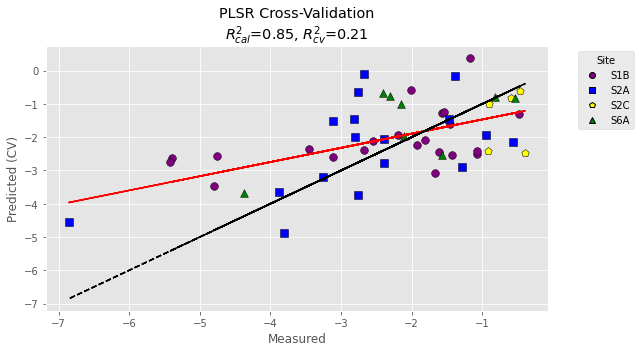

(array([-2.59147522, -3.45988487, -2.39905411, -2.56730068, -1.26274763,
        -0.57319961, -2.6143836 , -2.76036037, -1.24647672, -2.35429398,
        -2.2316822 , -1.60697003, -2.10046546, -1.28966329, -2.54531172,
        -3.06880749,  0.37650619, -2.45245146, -2.51664822, -2.07480993,
        -2.41562401, -1.92660934, -4.55622599, -4.86849352, -2.78412544,
        -2.04639691, -0.64662626, -2.89187067, -3.2080295 , -1.94887691,
        -3.72326778, -3.66235796, -1.45113851, -2.00739878, -2.15135217,
        -0.15123738, -1.52680592, -0.10838128, -1.45559418, -2.42528539,
        -0.61304301, -0.99667126, -0.80706904, -2.48140558, -0.80937008,
        -3.6818968 , -2.53221699, -0.78040144, -0.74660264, -1.01366755,
        -0.66673728, -1.96429494]),
 0.21030140779630946,
 0.8487681173933135,
 1.5917882784403865,
 0.30483673193342065)

In [27]:
file_name_d13c_max = r'D:\wenqu\chapter1_2\chapter2\pft_spectra\csv\graminoid.csv'
simple_pls_cv_label_category(opt_Xc, 
                             log10_y_graminoid,                         
                             ncomp, labels_graminoid, file_name_d13c_max)

In [ ]:
band_name[sorted_ind][wav:]

In [ ]:
# optimal_pls_d13c_max  = PLSRegression(n_components=45)
# optimal_pls_d13c_max.fit(opt_Xc_d13c_max, y_d13c_max[:, 0].astype(np.float64))

# coefficients_d13c_max = optimal_pls_d13c_max.coef_[:,0]
# bands_d13c_max = band_name[sorted_ind_d13c_max][wav_d13c_max:]

# print(coefficients_d13c_max.shape, bands_d13c_max.shape)

# coefficients_d13c_max

In [ ]:
opt_Xc.shape

In [ ]:
pls_final = PLSRegression(n_components=45, scale=True)
pls_final.fit(opt_Xc, y_graminoid)

In [ ]:
coef = pls_final.coef_  # Shape (n_features, 1)
coef
# x_mean = pls_final._x_mean  # (n_features,)
# x_std = pls_final._x_std    # (n_features,)
# y_mean = pls_final._y_mean  # (1,)

# # 2. Calculate transformed coefficients (for direct use on raw X)
# # These coefficients absorb all scaling factors
# transformed_coef = coef / x_std.reshape(-1, 1)
# transformed_intercept = y_mean - (x_mean / x_std) @ coef

# # 3. Prediction function (no data scaling needed)
# def predict_with_transformed_coef(X_new):
#     """Predict directly on raw/unscaled X_new"""
#     return X_new @ transformed_coef + transformed_intercept

# # 4. Verify against sklearn's predict()
# X_test = opt_Xc[:3]
# manual_pred = predict_with_transformed_coef(X_test).flatten()
# sklearn_pred = pls_final.predict(X_test).flatten()

# print("Manual predictions:", manual_pred)
# print("Sklearn predictions:", sklearn_pred)
# print("Max difference:", np.max(np.abs(manual_pred - sklearn_pred)))

# # This will pass (identical predictions)
# assert np.allclose(manual_pred, sklearn_pred, atol=1e-8)

In [ ]:
band_name[sorted_ind][wav:]

In [ ]:
# coef_list = transformed_coef.flatten().tolist()
# coef_list

In [ ]:
pls_final.intercept_

# lichen

In [25]:
ln_y_licen = np.log(y_licen)
# log10_y_graminoid = np.log(y_graminoid)

Component: 13, Features left for inner loop: 237, 59% completed

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  war

Component: 13, Features left for inner loop: 229, 59% completed

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  war

Component: 13, Features left for inner loop: 220, 59% completed

...

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 13
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 13
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 13
  war

Component: 20, Features left for inner loop: 22, 96% completed

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 13
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 13
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 13
  war

Component: 20, Features left for inner loop: 20, 96% completed

Suggested number of components: 8
Suggested number of bands to discard from left: 209
Features kept: [209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243]
Minimum LOOCV RMSE: 0.4365
R² (Calibration): 1.000
R² (Cross-validation): 0.573
MSE (Calibration): 0.000
MSE (Cross-validation): 0.258
Trend line: y = 0.525 * x + -1.519
0 -2.716571904226482 -2.450221089527383
1 -3.1757017174323487 -4.151039937398647
2 -3.712918925760266 -3.8501475897100588
3 -2.9643606700550476 -3.0143086510019264
4 -3.0157870503413418 -2.772588722239781
5 -3.8887936341908347 -4.8751972952011515
6 -3.7810534014326596 -4.00277737869661
7 -2.7750552025016746 -2.6300886606324982
8 -2.0232111004881177 -2.2823823888765262
9 -3.446109529783702 -2.772588722239781
10 -3.1460805137987538 -2.719100036288795
11 -3.7300292037674385 -3.1045866857

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 12
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 13
  war

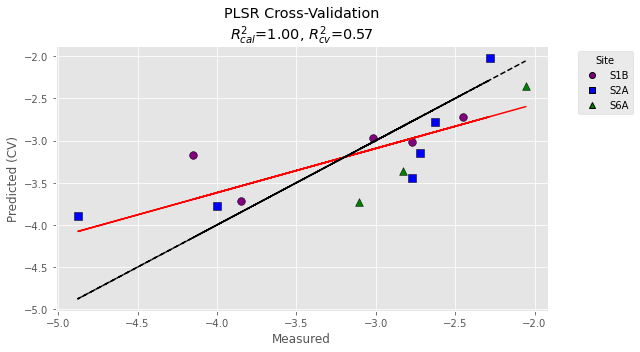

(array([-2.7165719 , -3.17570172, -3.71291893, -2.96436067, -3.01578705,
        -3.88879363, -3.7810534 , -2.7750552 , -2.0232111 , -3.44610953,
        -3.14608051, -3.7300292 , -3.36281249, -2.35883362]),
 0.5733668715942023,
 0.9996034903617387,
 0.25819635150369286,
 0.00023996575774058246)

In [26]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_licen, ln_y_licen, 20)
file_name_d13c_max = r'D:\wenqu\chapter1_2\chapter2\pft_spectra\csv\licen.csv'
simple_pls_cv_label_category(opt_Xc, 
                             ln_y_licen,                         
                             ncomp, labels_licen, file_name_d13c_max)


# X, y, n_comp,labels, filename

In [ ]:
band_name[sorted_ind][wav:]

In [ ]:
pls_final = PLSRegression(n_components=12, scale=True)
pls_final.fit(opt_Xc, y_licen)

In [ ]:
pls_final = PLSRegression(n_components=12, scale=True)
pls_final.fit(opt_Xc, y_licen)


coef = pls_final.coef_  # Shape (n_features, 1)
coef
# x_mean = pls_final._x_mean  # (n_features,)
# x_std = pls_final._x_std    # (n_features,)
# y_mean = pls_final._y_mean  # (1,)

# # 2. Calculate transformed coefficients (for direct use on raw X)
# # These coefficients absorb all scaling factors
# transformed_coef = coef / x_std.reshape(-1, 1)
# transformed_intercept = y_mean - (x_mean / x_std) @ coef

# # 3. Prediction function (no data scaling needed)
# def predict_with_transformed_coef(X_new):
#     """Predict directly on raw/unscaled X_new"""
#     return X_new @ transformed_coef + transformed_intercept

# # 4. Verify against sklearn's predict()
# X_test = opt_Xc[:5]
# manual_pred = predict_with_transformed_coef(X_test).flatten()
# sklearn_pred = pls_final.predict(X_test).flatten()

# print("Manual predictions:", manual_pred)
# print("Sklearn predictions:", sklearn_pred)
# print("Max difference:", np.max(np.abs(manual_pred - sklearn_pred)))

# # This will pass (identical predictions)
# assert np.allclose(manual_pred, sklearn_pred, atol=1e-8)

In [ ]:
pls_final.intercept_

# non-veg

In [27]:
# ln_y_nonveg = np.log(y_nonveg)

Component: 10, Features left for inner loop: 10, 98% completedd

Suggested number of components: 1
Suggested number of bands to discard from left: 0
Features kept: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 

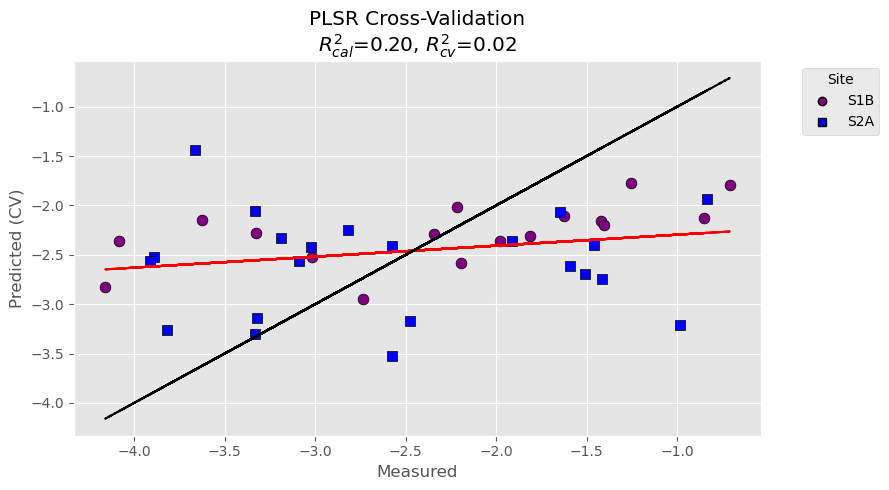

(array([-1.76985264, -1.79657232, -2.35932145, -2.15851717, -2.36257572,
        -2.12589715, -2.2799098 , -2.01840375, -2.31334214, -2.10713373,
        -2.15077887, -2.20248914, -2.29100833, -2.51934086, -2.82530735,
        -2.94564168, -2.58665148, -3.20938704, -3.16578145, -2.41784875,
        -2.35915823, -1.43698341, -3.52430089, -2.06240049, -2.74033149,
        -2.25008766, -2.69611643, -2.41492007, -1.93131526, -2.56585995,
        -3.13858878, -2.39715031, -2.52571986, -2.3329772 , -2.05902524,
        -2.61238869, -2.56400043, -3.30638983, -3.26132335]),
 0.01896274372271789,
 0.19790803039919014,
 0.9915979281356522,
 0.8107263308719925)

In [28]:
ln_y_nonveg = np.log(y_nonveg)
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_nonveg, ln_y_nonveg, 10)
file_name_d13c_max = r'D:\wenqu\chapter1_2\chapter2\pft_spectra\csv\non_veg.csv'
simple_pls_cv_label_category(opt_Xc, 
                             ln_y_nonveg,                         
                             ncomp, labels_nonveg, file_name_d13c_max)

In [ ]:
band_name[sorted_ind][wav:]

In [ ]:
pls_final = PLSRegression(n_components=39, scale=True)
pls_final.fit(opt_Xc, y_nonveg)


coef = pls_final.coef_  # Shape (n_features, 1)
coef
# x_mean = pls_final._x_mean  # (n_features,)
# x_std = pls_final._x_std    # (n_features,)
# y_mean = pls_final._y_mean  # (1,)

# # 2. Calculate transformed coefficients (for direct use on raw X)
# # These coefficients absorb all scaling factors
# transformed_coef = coef / x_std.reshape(-1, 1)
# transformed_intercept = y_mean - (x_mean / x_std) @ coef

# # 3. Prediction function (no data scaling needed)
# def predict_with_transformed_coef(X_new):
#     """Predict directly on raw/unscaled X_new"""
#     return X_new @ transformed_coef + transformed_intercept

# # 4. Verify against sklearn's predict()
# X_test = opt_Xc[:5]
# manual_pred = predict_with_transformed_coef(X_test).flatten()
# sklearn_pred = pls_final.predict(X_test).flatten()

# print("Manual predictions:", manual_pred)
# print("Sklearn predictions:", sklearn_pred)
# print("Max difference:", np.max(np.abs(manual_pred - sklearn_pred)))

# # This will pass (identical predictions)
# assert np.allclose(manual_pred, sklearn_pred, atol=1e-8)

In [ ]:
pls_final.intercept_

# Forbs

Component: 10, Features left for inner loop: 10, 98% completedd

Suggested number of components: 10
Suggested number of bands to discard from left: 137
Features kept: [137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243]
Minimum LOOCV RMSE: 0.7282
R² (Calibration): 0.966
R² (Cross-validation): 0.316
MSE (Calibration): 0.032
MSE (Cross-validation): 0.644
Trend line: y = 0.559 * x + -1.157
0 -3.2255319596555703 -4.110873902173312
1 -2.434522228062772 -4.06044302854642
2 -2.1618364399806964 -2.3112431560849864
3 -2.

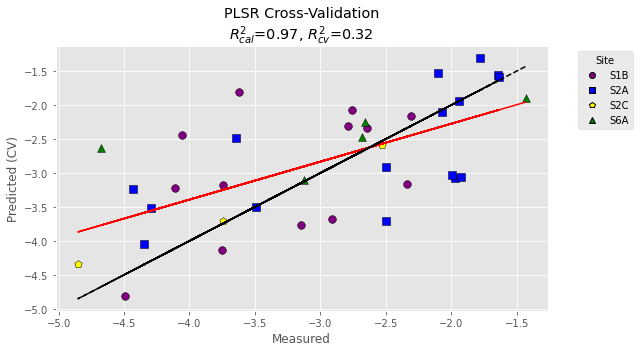

(array([-3.22553196, -2.43452223, -2.16183644, -2.07158209, -3.76180151,
        -3.68141384, -3.17648403, -1.81358905, -3.16075057, -2.33070043,
        -2.31495042, -4.13284943, -4.80405823, -2.48124168, -1.30961966,
        -1.52096322, -3.07573507, -3.06587727, -2.90608397, -3.02869425,
        -1.55726778, -1.93554835, -3.50488902, -3.70200796, -3.5110178 ,
        -2.10840473, -4.04779206, -1.58697917, -3.23180511, -2.58413266,
        -4.33978894, -3.70080192, -2.4776321 , -3.10598467, -2.24453124,
        -2.63941385, -1.90359233]),
 0.3164167578085707,
 0.9664536646224644,
 0.6443879103593959,
 0.03162285383832172)

In [26]:
# ln_y_nonveg = np.log(y_nonveg)
# opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_nonveg, ln_y_nonveg, 10)

ln_y_forb = np.log(y_forb)
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_forb, ln_y_forb, 10)

file_name_d13c_max = r'D:\wenqu\chapter1_2\chapter2\pft_spectra\csv\forb.csv'
simple_pls_cv_label_category(opt_Xc, 
                             ln_y_forb,                         
                             ncomp, labels_forb, file_name_d13c_max)

### pls_final = PLSRegression(n_components=47, scale=True)
pls_final.fit(opt_Xc, y_forb)


coef = pls_final.coef_ # Shape (n_features, 1)
coef
# x_mean = pls_final._x_mean  # (n_features,)
# x_std = pls_final._x_std    # (n_features,)
# y_mean = pls_final._y_mean  # (1,)

# # 2. Calculate transformed coefficients (for direct use on raw X)
# # These coefficients absorb all scaling factors
# transformed_coef = coef / x_std.reshape(-1, 1)
# transformed_intercept = y_mean - (x_mean / x_std) @ coef

# # 3. Prediction function (no data scaling needed)
# def predict_with_transformed_coef(X_new):
#     """Predict directly on raw/unscaled X_new"""
#     return X_new @ transformed_coef + transformed_intercept

# # 4. Verify against sklearn's predict()
# X_test = opt_Xc[:5]
# manual_pred = predict_with_transformed_coef(X_test).flatten()
# sklearn_pred = pls_final.predict(X_test).flatten()

# print("Manual predictions:", manual_pred)
# print("Sklearn predictions:", sklearn_pred)
# print("Max difference:", np.max(np.abs(manual_pred - sklearn_pred)))

# # This will pass (identical predictions)
# assert np.allclose(manual_pred, sklearn_pred, atol=1e-8)

In [ ]:
band_name[sorted_ind][wav:]

In [ ]:
pls_final.intercept_

# evergreen

Component: 19, Features left for inner loop: 241, 87% completed

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  war

Component: 19, Features left for inner loop: 236, 87% completed

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  war

Component: 19, Features left for inner loop: 231, 87% completed

...

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  war

Component: 20, Features left for inner loop: 22, 96% completed

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  war

Component: 20, Features left for inner loop: 20, 96% completed

Suggested number of components: 6
Suggested number of bands to discard from left: 4
Features kept: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191

C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 18
  warnings.warn(f"Y residual is constant at iteration {k}")
C:\Users\laral\Anaconda3\envs\wenqu_gpu\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 19
  war

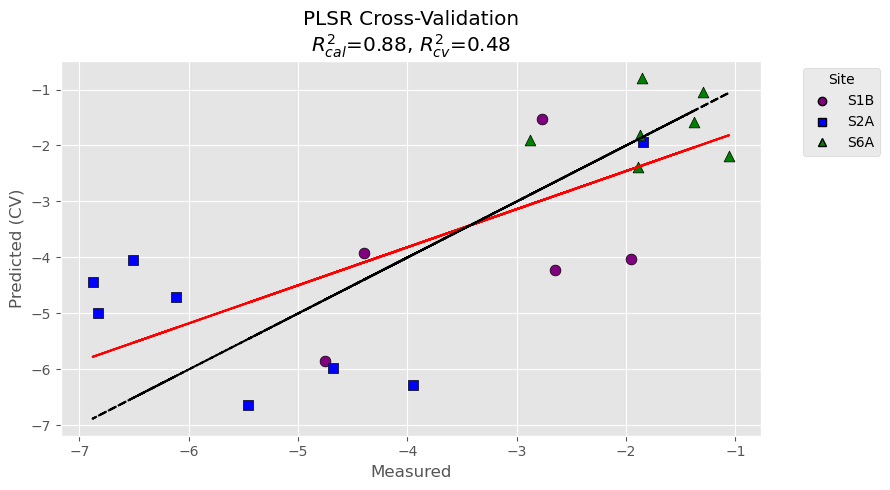

(array([-5.85122554, -4.02073433, -4.2323047 , -3.91462096, -1.52630833,
        -5.96819774, -6.63696633, -6.27224121, -4.04161838, -4.71305643,
        -4.98449683, -4.43620776, -1.93747597, -0.79453515, -1.58620941,
        -2.37783207, -1.89606957, -2.18616026, -1.03784079, -1.8051114 ]),
 0.48344879662627105,
 0.8803684441588314,
 1.967744323525928,
 0.45572309847222947)

In [29]:
ln_y_evergreen_shrub = np.log(y_evergreen_shrub)
# opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_nonveg, ln_y_nonveg, 10)

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_evergreen_shrub, ln_y_evergreen_shrub, 20)

file_name_d13c_max = r'D:\wenqu\chapter1_2\chapter2\pft_spectra\csv\evergreen_shrub.csv'
simple_pls_cv_label_category(opt_Xc, 
                             ln_y_evergreen_shrub,                         
                             ncomp, labels_evergreen_shrub, file_name_d13c_max)

In [ ]:
pls_final = PLSRegression(n_components=2, scale=True)
pls_final.fit(opt_Xc, y_evergreen_shrub)


coef = pls_final.coef_  # Shape (n_features, 1)
coef
# x_mean = pls_final._x_mean  # (n_features,)
# x_std = pls_final._x_std    # (n_features,)
# y_mean = pls_final._y_mean  # (1,)

# # 2. Calculate transformed coefficients (for direct use on raw X)
# # These coefficients absorb all scaling factors
# transformed_coef = coef / x_std.reshape(-1, 1)
# transformed_intercept = y_mean - (x_mean / x_std) @ coef

# # 3. Prediction function (no data scaling needed)
# def predict_with_transformed_coef(X_new):
#     """Predict directly on raw/unscaled X_new"""
#     return X_new @ transformed_coef + transformed_intercept

# # 4. Verify against sklearn's predict()
# X_test = opt_Xc[:5]
# manual_pred = predict_with_transformed_coef(X_test).flatten()
# sklearn_pred = pls_final.predict(X_test).flatten()

# print("Manual predictions:", manual_pred)
# print("Sklearn predictions:", sklearn_pred)
# print("Max difference:", np.max(np.abs(manual_pred - sklearn_pred)))

# # This will pass (identical predictions)
# assert np.allclose(manual_pred, sklearn_pred, atol=1e-8)

In [ ]:
band_name[sorted_ind][wav:]

In [ ]:
pls_final.intercept_

# deciduous_shrub

Component: 20, Features left for inner loop: 20, 96% completedd

Suggested number of components: 4
Suggested number of bands to discard from left: 187
Features kept: [187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243]
Minimum LOOCV RMSE: 0.6128
R² (Calibration): 0.631
R² (Cross-validation): 0.420
MSE (Calibration): 0.232
MSE (Cross-validation): 0.365
Trend line: y = 0.464 * x + -0.773
0 -2.3301808049378367 -1.8607523442864349
1 -2.064817470379459 -1.2776605222347424
2 -1.6968716245508166 -1.352392808110876
3 -1.3075208179956448 -1.4036861004633387
4 -1.043254633537785 -0.23531408648548538
5 -1.6992099578661475 -1.3091770581192093
6 -0.9658450046352873 -0.8892620597529024
7 -1.3376059525639385 -1.2264456579052674
8 -1.3272679664750995 -1.103106675310003
9 -

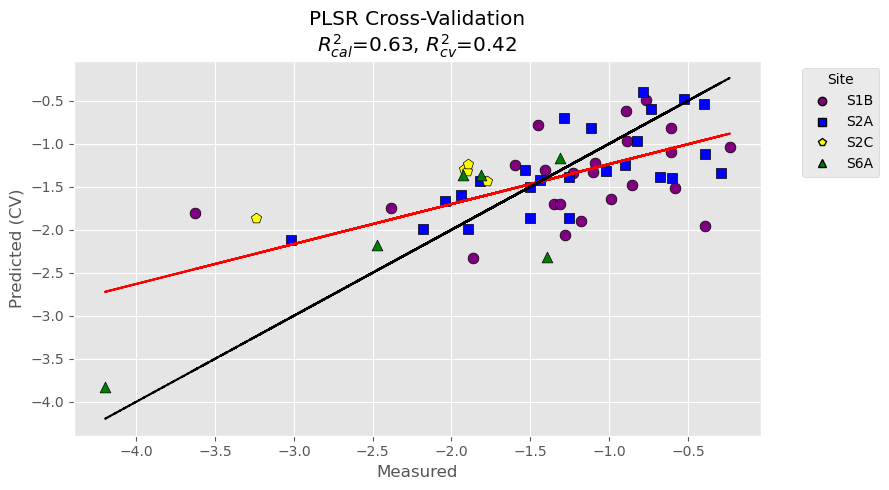

(array([-2.3301808 , -2.06481747, -1.69687162, -1.30752082, -1.04325463,
        -1.69920996, -0.965845  , -1.33760595, -1.32726797, -0.61652604,
        -1.48237787, -1.80093521, -0.81593045, -0.49102162, -1.63848488,
        -1.5094763 , -1.09386535, -1.90307039, -0.78593164, -1.75072774,
        -1.24540656, -1.22650296, -1.95992422, -0.59632877, -0.53329677,
        -1.12402303, -0.47855162, -1.86682682, -2.11468328, -0.96918794,
        -1.38242798, -0.70117921, -1.39995317, -1.66145838, -1.41665503,
        -1.43401062, -1.5062779 , -0.81800812, -1.86021877, -1.30806784,
        -1.59563952, -1.34366383, -1.31331725, -1.99283232, -1.99123351,
        -0.39666211, -1.24881832, -1.38275064, -1.43138881, -1.8604707 ,
        -1.29156125, -1.31295511, -1.23743362, -1.16297415, -1.36765473,
        -2.17912289, -2.31551575, -3.83231975, -1.35983616]),
 0.4202330064023567,
 0.6314313303186649,
 0.36508615033761704,
 0.23209206152635733)

In [26]:
ln_y_deciduous_shrub= np.log(y_deciduous_shrub)
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_deciduous_shrub, ln_y_deciduous_shrub, 20)

# opt_Xc, ncomp, wav, sorted_pls_band_component(x_deciduous_shrub, ln_y_deciduous_shrub, 10)

file_name_d13c_max = r'D:\wenqu\chapter1_2\chapter2\pft_spectra\csv\deciduous_shrub.csv'
# simple_pls_cv_label_category(opt_Xc, 
#                              ln_y_deciduous_shrub,                         
#                              ncomp, labels_deciduous_shrub, file_name_d13c_max)

simple_pls_cv_label_category(opt_Xc, 
                             ln_y_deciduous_shrub,                         
                             ncomp, labels_deciduous_shrub, file_name_d13c_max)

In [ ]:
pls_final = PLSRegression(n_components=28, scale=True)
pls_final.fit(opt_Xc, y_deciduous_shrub)


coef = pls_final.coef_ # Shape (n_features, 1)
coef
# x_mean = pls_final._x_mean  # (n_features,)
# x_std = pls_final._x_std    # (n_features,)
# y_mean = pls_final._y_mean  # (1,)

# # 2. Calculate transformed coefficients (for direct use on raw X)
# # These coefficients absorb all scaling factors
# transformed_coef = coef / x_std.reshape(-1, 1)
# transformed_intercept = y_mean - (x_mean / x_std) @ coef

# # 3. Prediction function (no data scaling needed)
# def predict_with_transformed_coef(X_new):
#     """Predict directly on raw/unscaled X_new"""
#     return X_new @ transformed_coef + transformed_intercept

# # 4. Verify against sklearn's predict()
# X_test = opt_Xc[:5]
# manual_pred = predict_with_transformed_coef(X_test).flatten()
# sklearn_pred = pls_final.predict(X_test).flatten()

# print("Manual predictions:", manual_pred)
# print("Sklearn predictions:", sklearn_pred)
# print("Max difference:", np.max(np.abs(manual_pred - sklearn_pred)))

# # This will pass (identical predictions)
# assert np.allclose(manual_pred, sklearn_pred, atol=1e-8)

In [ ]:
band_name[sorted_ind][wav:]

In [ ]:
pls_final.intercept_

# standing_dead

In [ ]:
opt_Xc, ncomp, wav, sorted_ind = pls_variable_selection(x_standing_dead, y_standing_dead, 50)

file_name_d13c_max = r'D:\wenqu\chapter1_2\chapter2\pft_spectra\csv\standing_dead.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_standing_dead,                         
                             ncomp, labels_standing_dead, file_name_d13c_max)

In [ ]:
y_forb = df_forb_spectra['Percent_Cover'].to_numpy()
y_evergreen_shrub = df_evergreen_shrub_spectra['Percent_Cover'].to_numpy()
y_deciduous_shrub = df_deciduous_shrub_spectra['Percent_Cover'].to_numpy()
y_standing_dead = df_standing_dead['Percent_Cover'].to_numpy()

x_forb = np.array(df_forb_spectra[band_name])
x_evergreen_shrub = np.array(df_evergreen_shrub_spectra[band_name])
x_deciduous_shrub = np.array(df_deciduous_shrub_spectra[band_name])
x_standing_dead = np.array(df_standing_dead[band_name])

labels_forb
labels_evergreen_shrub
labels_deciduous_shrub
labels_standing_dead